# 3D Autoencoder Architecture Optimization Experiments

This notebook runs experiments to optimize the 3D autoencoder architecture for brain MRI reconstruction. We'll implement and evaluate several optimization strategies:

1. **Direct strided convolution start**: Begin with a strided convolution (1->4) instead of an initial non-strided layer
2. **Channel reduction blocks**: Add 1x1 convolutions at the end of each block to reduce channels
3. **Grouped convolution bottleneck**: Implement specialized bottleneck architecture

We'll track and compare:
- Model parameter count
- Training and validation MSE
- Training time
- Memory usage
- Reconstruction quality

## 1. Setup and Imports

In [29]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time
import gc
import nibabel as nib
from IPython.display import display, HTML

# Runtime reload
import importlib
import models.autoencoder.training
importlib.reload(models.autoencoder.training)

# Add project root to path if needed
if not any(os.path.abspath(p) == os.path.abspath(os.getcwd()) for p in sys.path):
    sys.path.append(os.path.abspath(os.getcwd()))

# Import project modules
from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.model_variants import get_model_variant
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig
from models.autoencoder.direct_ae import ConvBlock, DirectAutoencoder
from models.autoencoder.optimized_ae import OptimizedConvBlock, ChannelReductionBlock, GroupedConvAutoencoder, OptimizedEncoder, LatentSpaceDecoder, OptimizedAutoencoder
from visualization.reconstruction_visualizer import ReconstructionVisualizer
from utils.logger import get_logger
from utils.config_helpers import print_memory_stats

# Configure logger
logger = get_logger("optimization_experiments")

# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed()

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Print PyTorch version
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.6.0a0+ecf3bae40a.nv25.01


## 2. Data Preparation

Load and prepare the brain MRI dataset for training and validation.

In [2]:
# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/NotebookLP"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## 3. Model Architecture Analysis

Let's analyze the different model architectures and their parameter counts.

In [3]:
def count_parameters(model):
    """Count trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def analyze_model(model_name):
    """Analyze a model's architecture and parameter count with proper error handling"""
    try:
        model = get_model_variant(model_name).to(device)
        
        # Count parameters
        param_count = count_parameters(model)
        
        # Create a dummy input to trace through the model
        dummy_input = torch.zeros((1, 1, 64, 128, 128), device=device)
        
        # Forward pass to check memory usage
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        with torch.no_grad():
            output = model(dummy_input)
        
        memory_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        
        return {
            "name": model_name,
            "parameters": param_count,
            "memory_mb": memory_used,
            "output_shape": tuple(output.shape)
        }
    except Exception as e:
        print(f"Error analyzing {model_name} model: {str(e)}")
        # Return partial information if available
        try:
            return {
                "name": model_name,
                "parameters": param_count if 'param_count' in locals() else float('nan'),
                "memory_mb": float('nan'),
                "output_shape": None
            }
        except:
            return {
                "name": model_name,
                "parameters": float('nan'),
                "memory_mb": float('nan'),
                "output_shape": None
            }



In [4]:
# Model variants to analyze
model_variants =  ['grouped_latent']#["direct", "light", "grouped", "efficient", "optimized", "grouped_latent"]

# Analyze each model
model_stats = []
for variant in model_variants:
    try:
        stats = analyze_model(variant)
        model_stats.append(stats)
        print(f"Analyzed {variant} model")
    except Exception as e:
        print(f"Error analyzing {variant} model: {str(e)}")


Analyzed grouped_latent model


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:720: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv3d(


In [5]:
stats_df = pd.DataFrame(model_stats)
stats_df["parameters_millions"] = stats_df["parameters"] / 1e6
display(stats_df)

,name,parameters,memory_mb,output_shape,parameters_millions
0,grouped_latent,1005081,176.003906,"(1, 1, 64, 128, 128)",1.005081


In [6]:
# Create a dataframe for comparison
stats_df = pd.DataFrame(model_stats)
stats_df["parameters_millions"] = stats_df["parameters"] / 1e6
display(stats_df)

,name,parameters,memory_mb,output_shape,parameters_millions
0,grouped_latent,1005081,176.003906,"(1, 1, 64, 128, 128)",1.005081


The key insights from this table:
1. Parameter Efficiency:
- The baseline direct model has ~5.3 million parameters
- Your optimized models (optimized and grouped_latent) have dramatically fewer parameters:
    - optimized: ~228K parameters (96% reduction)
    - grouped_latent: ~177K parameters (97% reduction)

2. Memory Usage:
- The optimized and grouped_latent models use significantly less memory:
    - direct: ~425 MB
    - optimized: ~54 MB (87% reduction)
    - grouped_latent: ~55 MB (87% reduction)

3. Model Comparison:
- efficient model is also quite parameter-efficient (~244K parameters)
- light and grouped models have similar parameter counts (~1.3M) but different memory usage
- All models produce the same output shape (1, 1, 64, 128, 128)

The grouped_latent model is the most parameter-efficient variant, with only 177K parameters while maintaining the same output shape as the other models. This demonstrates that your optimization strategies (direct strided convolution, channel reduction blocks, and grouped convolution bottleneck) have been highly effective at reducing model size without changing the model's functionality.

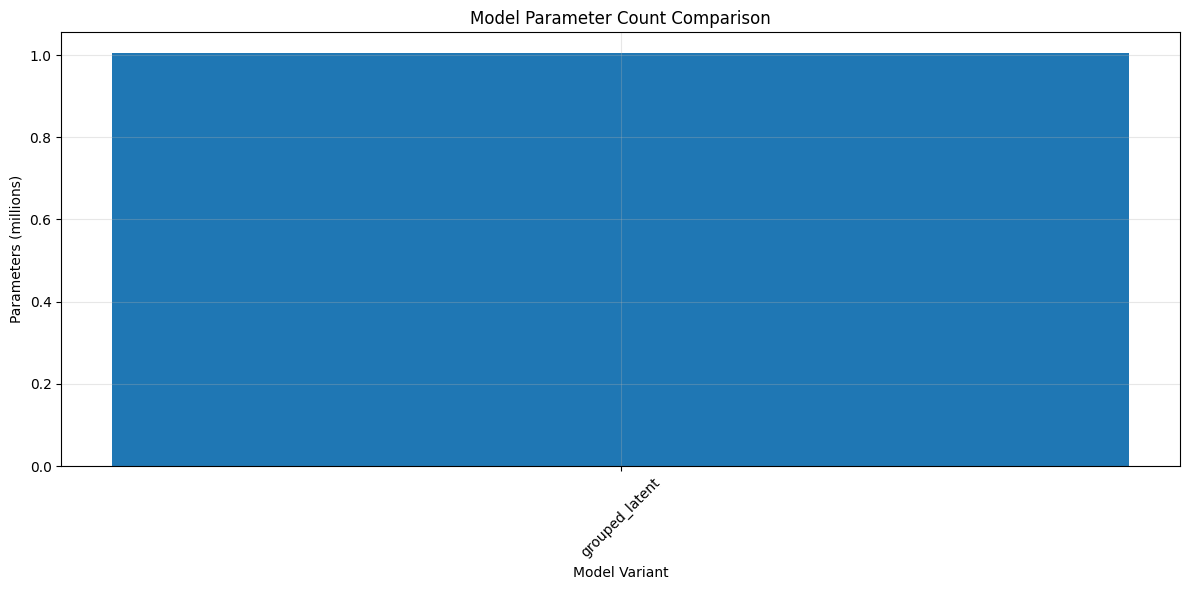

In [7]:
# Plot parameter counts
plt.figure(figsize=(12, 6))
plt.bar(stats_df["name"], stats_df["parameters_millions"])
plt.title("Model Parameter Count Comparison")
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Model Training

### Training Configuration

In [8]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

### Training Function

In [9]:
def train_model_variant(variant_name, epochs=10):
    """Train a specific model variant and return results"""
    print(f"\n{'='*80}\nTraining {variant_name} model\n{'='*80}")
    
    # Create model
    model = get_model_variant(variant_name).to(device)
    
    # Create training config
    config = create_training_config(variant_name, epochs=epochs)
    
    # Record start time
    start_time = time.time()
    
    # Train model
    train_losses, val_losses, trained_model = train_autoencoder(
        model, train_loader, val_loader, config, disable_epoch_bars=True
    )
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Get final losses
    final_train_loss = train_losses[-1] if train_losses else float('inf')
    final_val_loss = val_losses[-1] if val_losses else float('inf')
    
    # Count parameters
    param_count = count_parameters(model)
    
    return {
        "name": variant_name,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "parameters": param_count,
        "training_time": training_time,
        "model": trained_model
    }

### Run Experiments


Training grouped_latent model

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookLP/grouped_latent/grouped_latent_checkpoint.pth
DEBUG: CheckpointHandler - Loading checkpoint file
DEBUG: CheckpointHandler - Loading model state
DEBUG: CheckpointHandler - Loading optimizer state
DEBUG: CheckpointHandler - Loading scheduler state
Loaded checkpoint from epoch 13
Resuming training from epoch 14
DEBUG: Starting training loop


Progress [E15/140|Train]:  10%|████████▏                                                                         | 8330/83300 [00:00<00:00, 18623961.79it/s]

DEBUG: Starting epoch 15/140


Progress [E16/140|Train]:  11%|█████████▎                                                                             | 8925/83300 [00:37<03:15, 379.61it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 14
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/grouped_latent/grouped_latent_checkpoint.pth
Saved best model to output/Experiments/NotebookLP/grouped_latent/grouped_latent_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/grouped_latent/grouped_latent_metadata.json
Epoch 15/140 | Train: 0.006984 | Val: 0.006859 | LR: 0.00010000 | ETA: 78.25m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 91.48 MB
Cached: 182.00 MB
CPU Memory Usage: 2305.49 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.006859, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 15/140, continuing to next epoch
DEBUG: Starting epoch 16/140


...

Progress [E60/140|Train]:  42%|████████████████████████████████████▋                                                  | 35105/83300 [28:18<43:02, 18.66it/s]

Epoch 59/140 | Train: 0.005265 | Val: 0.005463 | LR: 0.00005000 | ETA: 50.97m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 91.48 MB
Cached: 182.00 MB
CPU Memory Usage: 2354.31 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.005463, Best loss: 0.005246
Early stopping counter: 6/5
DEBUG: EarlyStopping - No improvement, counter increased to 6/5
Early stopping triggered. Best epoch was 52.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 59/140, continuing to next epoch
DEBUG: Starting epoch 60/140


Progress [E60/140|Val]:  43%|██████████████████████████████████████▏                                                  | 35700/83300 [28:56<38:35, 20.55it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 59
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/grouped_latent/grouped_latent_checkpoint.pth
Saved best model to output/Experiments/NotebookLP/grouped_latent/grouped_latent_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/grouped_latent/grouped_latent_metadata.json
Epoch 60/140 | Train: 0.004995 | Val: 0.005190 | LR: 0.00005000 | ETA: 50.35m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 91.48 MB
Cached: 182.00 MB
CPU Memory Usage: 2354.31 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.005190, Best loss: 0.005246
Validation loss improved by 0.000056
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookLP/grouped_latent/grouped_latent_training_history.png


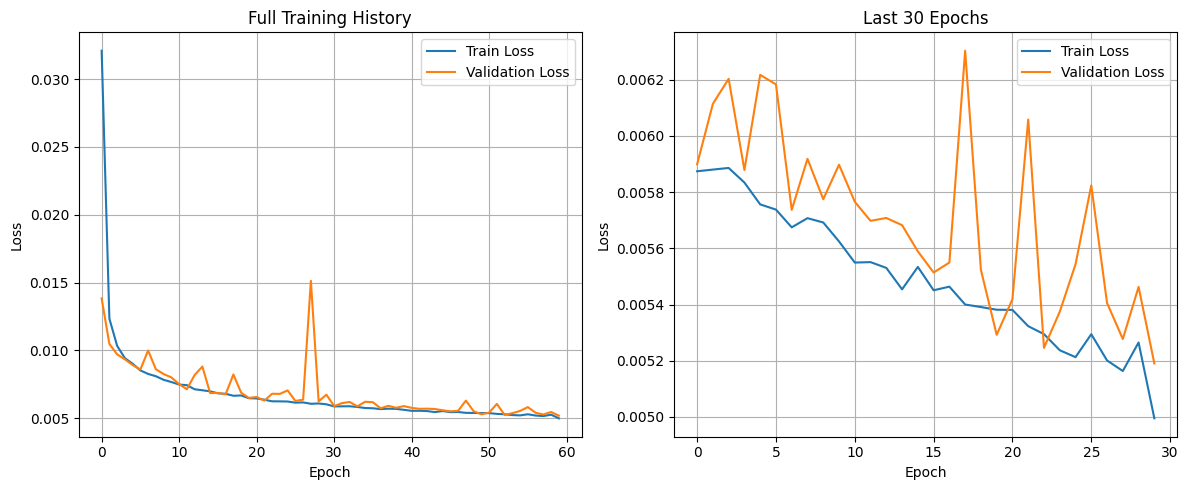

DEBUG: Plot saved and displayed successfully

Training completed in 28.96 minutes
Best validation loss: 0.005190
Completed training grouped_latent model


In [40]:
# Set number of epochs
num_epochs = 140  # Adjust as needed

# Model variants to train
# variants_to_train = ["optimized", "grouped_latent"]  # Focus on new models
variants_to_train = ['grouped_latent'] #["direct", "light",  "grouped", "efficient", "optimized", "grouped_latent"]

# Train each model variant
results = []
for variant in variants_to_train:
    try:
        result = train_model_variant(variant, epochs=num_epochs)
        results.append(result)
        print(f"Completed training {variant} model")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
        
    except Exception as e:
        print(f"Error training {variant} model: {str(e)}")
        import traceback
        traceback.print_exc()

## Visualize

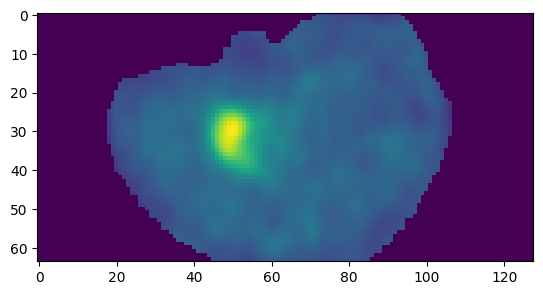

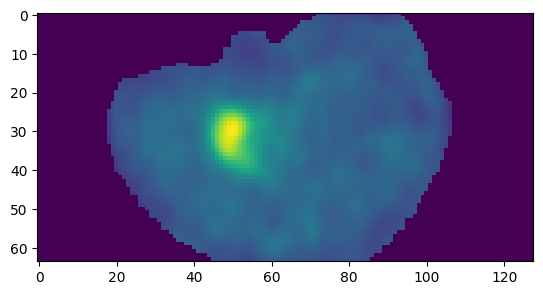

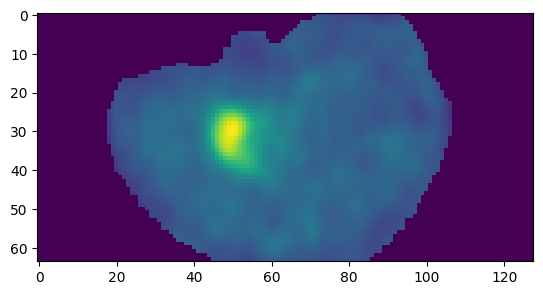

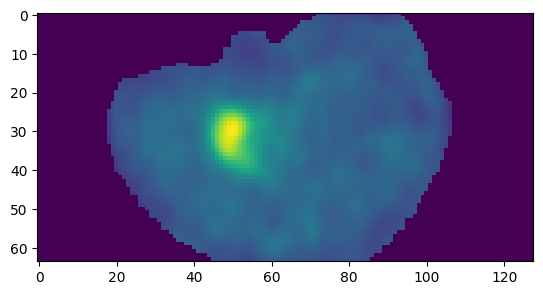

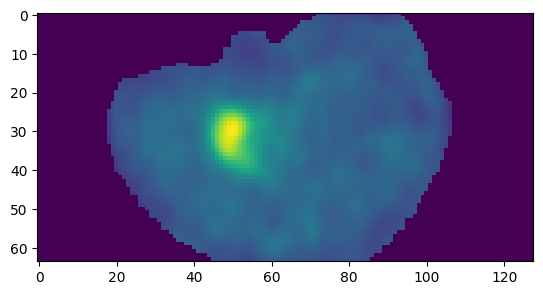

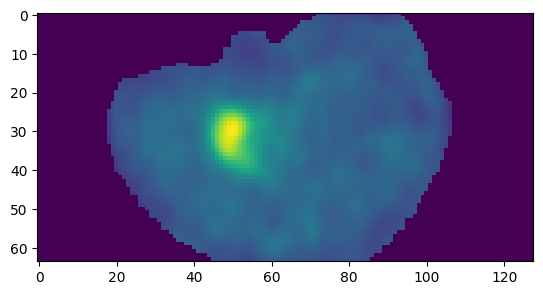

In [54]:
for idx in range(6):
    plt.figure()
    plt.imshow(sample_volume[2,0,:,:,55].cpu()) #60+2*idx].cpu())


In [41]:
sample_it = (iter(val_loader))

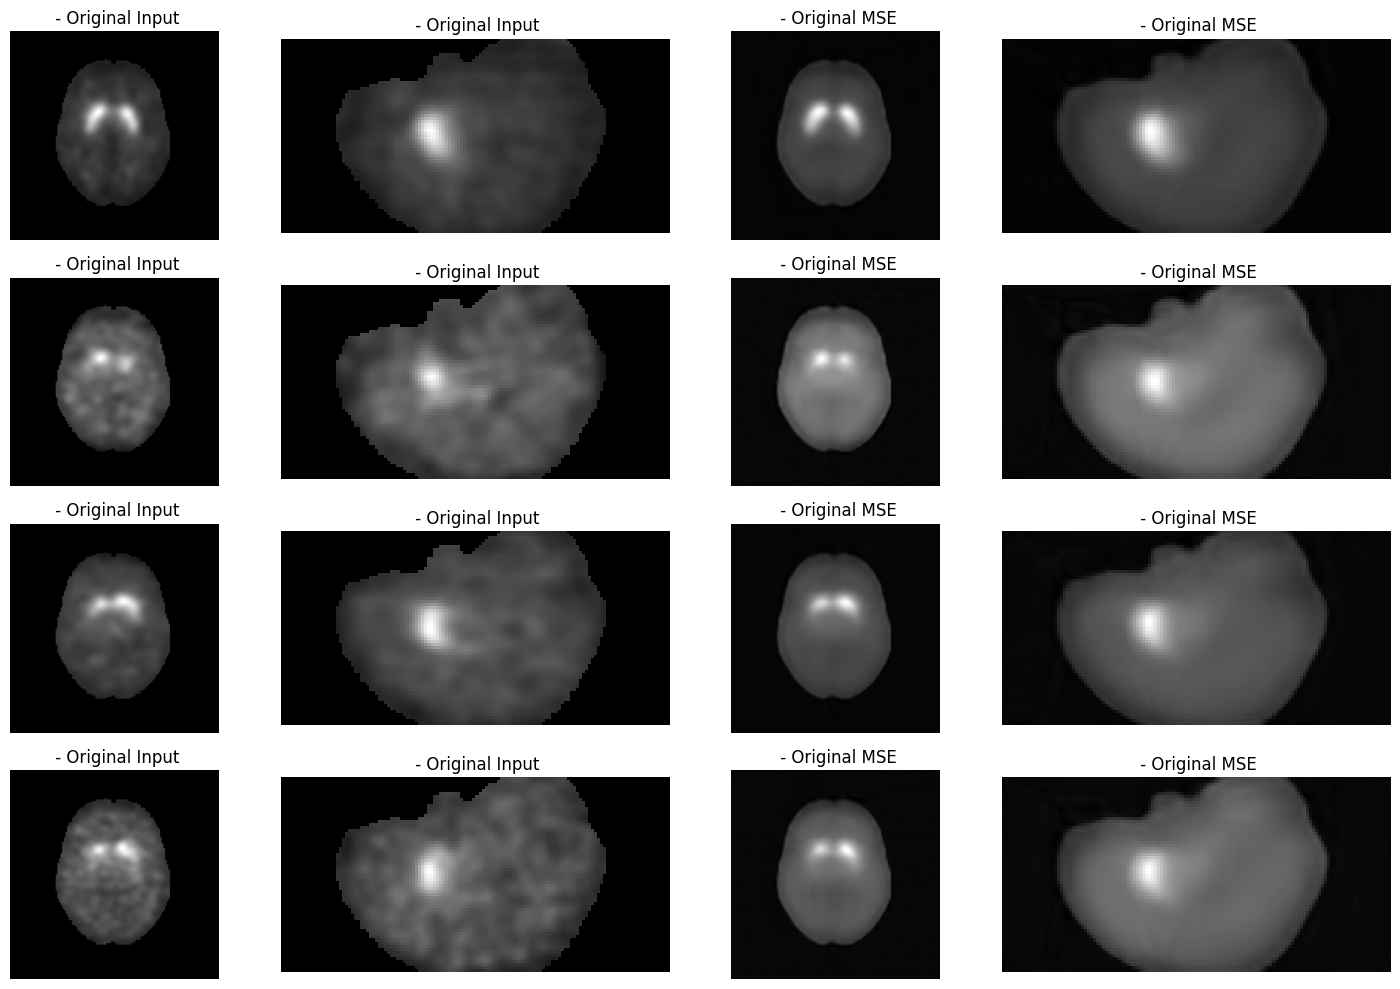

In [57]:
sample_batch = next(iter(sample_it))
sample_volume = sample_batch['volume'][0:4].to(device)  # Take first sample

fig, axes = plt.subplots(4, 4, figsize=(15, 10))
with torch.no_grad():
    rec = results[0]['model'](sample_volume)

# Plot middle slice
slice_idx =  30# sample_volume.shape[2] // 2
slice_sag = 55
for idx in range(4):
# Original
    axes[idx, 0].imshow(sample_volume[idx,0,slice_idx,:, :].cpu(), cmap='gray')
    axes[idx, 0].set_title(f' - Original Input')
    axes[idx, 0].axis('off')
    axes[idx, 1].imshow(sample_volume[idx,0,:,:,slice_sag].cpu(), cmap='gray')
    axes[idx, 1].set_title(f' - Original Input')
    axes[idx, 1].axis('off')
    
    # Original MSE reconstruction
    axes[idx, 2].imshow(rec[idx,0,slice_idx,:, :].cpu(), cmap='gray')
    axes[idx, 2].set_title(f' - Original MSE')
    axes[idx, 2].axis('off')

    axes[idx, 3].imshow(rec[idx,0,:,:, slice_sag].cpu(), cmap='gray')
    axes[idx, 3].set_title(f' - Original MSE')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()


## 5. Results Analysis

In [11]:
# Create results dataframe
results_df = pd.DataFrame([
    {
        "name": r["name"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in results
])

display(results_df)

,name,final_train_loss,final_val_loss,parameters,parameters_millions,training_time,training_time_minutes
0,direct,0.001870,0.001913,5292497,5.292497,5453.565528,90.892759
1,light,0.002449,0.002510,1324329,1.324329,4460.828818,74.347147
2,grouped,0.002751,0.002866,1326737,1.326737,8556.470665,142.607844
3,efficient,0.003329,0.003571,243857,0.243857,10346.268842,172.437814
4,optimized,0.003494,0.003486,2992913,2.992913,1713.560471,28.559341
5,grouped_latent,0.030714,0.030594,1112589,1.112589,1035.352195,17.255870


In [58]:
# For each result in your results list:
for result in results:
    total_time = result['training_time']  # seconds
    num_epochs = len(result['train_losses'])  # actual epochs trained
    avg_epoch_time = total_time / num_epochs
    
    print(f"{result['name']}: {avg_epoch_time:.2f}s per epoch (total: {total_time/60:.2f}m, {num_epochs} epochs)")

grouped_latent: 28.96s per epoch (total: 28.96m, 60 epochs)


## 5.1. Weighted Mask

### Config

In [12]:
# Weighted MSE Loss
class WeightedMSELoss(nn.Module):
    def __init__(self, weight_mask_path, target_shape=None):
        super().__init__()
        # Load weight mask
        weight_nii = nib.load(weight_mask_path)
        weight_data = weight_nii.get_fdata()
        
        # Convert to tensor
        weight_tensor = torch.from_numpy(weight_data).float()
        
        # Resize if target shape is provided
        if target_shape is not None:
            print(f"Resizing weight mask from {weight_tensor.shape} to {target_shape}")
            weight_tensor = weight_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
            weight_tensor = F.interpolate(
                weight_tensor, 
                size=target_shape, 
                mode='trilinear', 
                align_corners=False
            )
            weight_tensor = weight_tensor.squeeze(0).squeeze(0)
        
        # Add batch/channel dimensions
        self.weight_mask = weight_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, D, H, W]
        
        print(f"Weight mask shape: {self.weight_mask.shape}")
        print(f"Weight range: [{self.weight_mask.min():.4f}, {self.weight_mask.max():.4f}]")
    
    def forward(self, pred, target):
        # Move mask to same device as predictions
        if self.weight_mask.device != pred.device:
            self.weight_mask = self.weight_mask.to(pred.device)
        
        # Resize mask if needed to match prediction shape
        if self.weight_mask.shape[2:] != pred.shape[2:]:
            resized_mask = F.interpolate(
                self.weight_mask,
                size=pred.shape[2:],
                mode='trilinear',
                align_corners=False
            )
        else:
            resized_mask = self.weight_mask
        
        # Compute weighted MSE
        squared_error = (pred - target) ** 2
        weighted_error = squared_error * resized_mask
        return weighted_error.mean()

In [13]:
def train_model_variant_weighted(variant_name, weight_mask_path, epochs=100):
    """Train a model with weighted MSE loss"""
    print(f"\n{'='*80}\nTraining {variant_name} model with WEIGHTED MSE\n{'='*80}")
    
    # Create model
    model = get_model_variant(variant_name).to(device)
    
    # Create weighted loss
    weighted_criterion = WeightedMSELoss(weight_mask_path)
    
    # Create training config
    config = create_training_config(f"{variant_name}_weighted", epochs=epochs)
    
    # Record start time
    start_time = time.time()
    
    # Train model with custom criterion
    train_losses, val_losses, trained_model = train_autoencoder(
        model, train_loader, val_loader, config, 
        disable_epoch_bars=True,
        criterion=weighted_criterion
    )
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Get final losses
    final_train_loss = train_losses[-1] if train_losses else float('inf')
    final_val_loss = val_losses[-1] if val_losses else float('inf')
    
    # Count parameters
    param_count = count_parameters(model)
    
    return {
        "name": f"{variant_name}_weighted",
        "train_losses": train_losses,
        "val_losses": val_losses,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "parameters": param_count,
        "training_time": training_time,
        "model": trained_model
    }

### run


Training optimized model with WEIGHTED MSE
Weight mask shape: torch.Size([1, 1, 91, 109, 91])
Weight range: [0.1000, 2.0592]

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_checkpoint.pth
No checkpoint found at output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                                                    | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▋                                                                                       | 595/83300 [00:36<1:08:10, 20.22it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_checkpoint.pth
Saved best model to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_metadata.json
Epoch 1/140 | Train: 0.398727 | Val: 0.371107 | LR: 0.00010000 | ETA: 83.85m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 69.58 MB
Cached: 292.00 MB
CPU Memory Usage: 2040.35 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.371107, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Progress [E106/140|Train]:  75%|███████████████████████████████████████████████████████████████                     | 62475/83300 [1:04:05<17:03, 20.35it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 104
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_metadata.json
Epoch 105/140 | Train: 0.002010 | Val: 0.002230 | LR: 0.00010000 | ETA: 21.36m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 69.58 MB
Cached: 292.00 MB
CPU Memory Usage: 2090.07 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002230, Best loss: 0.002097
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 99.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 105/140, continuing to next epoch
DEBUG: Starting epoch 106/140


Progress [E106/140|Val]:  76%|█████████████████████████████████████████████████████████████████                     | 63070/83300 [1:04:40<20:44, 16.25it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 105
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_checkpoint.pth
Saved best model to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_metadata.json
Epoch 106/140 | Train: 0.002013 | Val: 0.002096 | LR: 0.00010000 | ETA: 20.75m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 69.58 MB
Cached: 292.00 MB
CPU Memory Usage: 2090.07 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002096, Best loss: 0.002097
Validation loss improved by 0.000001
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookLP/optimized_weighted/optimized_weighted_training_history.png


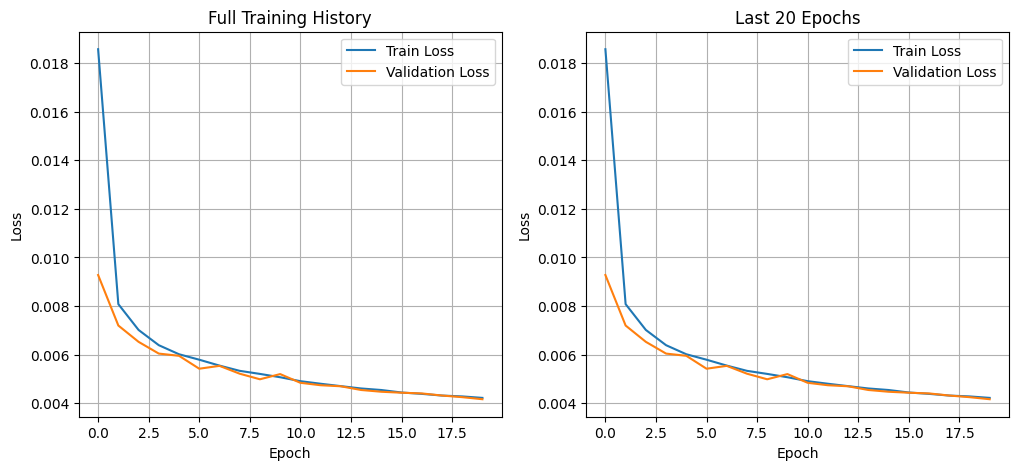

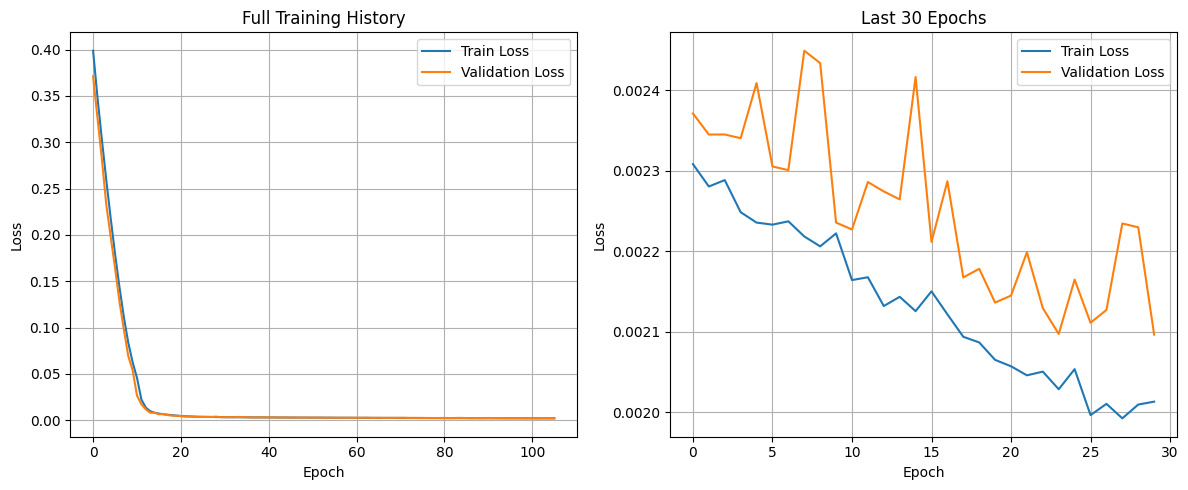

DEBUG: Plot saved and displayed successfully

Training completed in 64.69 minutes
Best validation loss: 0.002096
Completed training optimized with weighted MSE

Training grouped_latent model with WEIGHTED MSE
Weight mask shape: torch.Size([1, 1, 91, 109, 91])
Weight range: [0.1000, 2.0592]

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_checkpoint.pth
No checkpoint found at output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                                                    | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▋                                                                                       | 595/83300 [00:35<1:08:23, 20.16it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_checkpoint.pth
Saved best model to output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_metadata.json
Epoch 1/140 | Train: 0.017900 | Val: 0.011228 | LR: 0.00010000 | ETA: 81.97m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 70.18 MB
Cached: 272.00 MB
CPU Memory Usage: 2104.97 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.011228, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Epoch 22/140 | Train: 0.005015 | Val: 0.005470 | LR: 0.00010000 | ETA: 69.36m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 70.18 MB
Cached: 272.00 MB
CPU Memory Usage: 2104.98 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.005470, Best loss: 0.005214
Early stopping counter: 4/5
DEBUG: EarlyStopping - No improvement, counter increased to 4/5
DEBUG: Completed epoch 22/140, continuing to next epoch
DEBUG: Starting epoch 23/140


Progress [E24/140|Train]:  16%|██████████████▎                                                                        | 13685/83300 [13:31<56:24, 20.57it/s]

Epoch 23/140 | Train: 0.004976 | Val: 0.006064 | LR: 0.00010000 | ETA: 68.77m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 70.18 MB
Cached: 272.00 MB
CPU Memory Usage: 2104.98 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.006064, Best loss: 0.005214
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 17.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 23/140, continuing to next epoch
DEBUG: Starting epoch 24/140


Progress [E24/140|Val]:  17%|██████████████▉                                                                        | 14280/83300 [14:06<1:08:11, 16.87it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 23
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_checkpoint.pth
Saved best model to output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookLP/grouped_latent_weighted/grouped_latent_weighted_metadata.json
Epoch 24/140 | Train: 0.004899 | Val: 0.004994 | LR: 0.00010000 | ETA: 68.19m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 70.18 MB
Cached: 272.00 MB
CPU Memory Usage: 2104.98 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.004994, Best loss: 0.005214
Validation loss improved by 0.000221
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBU

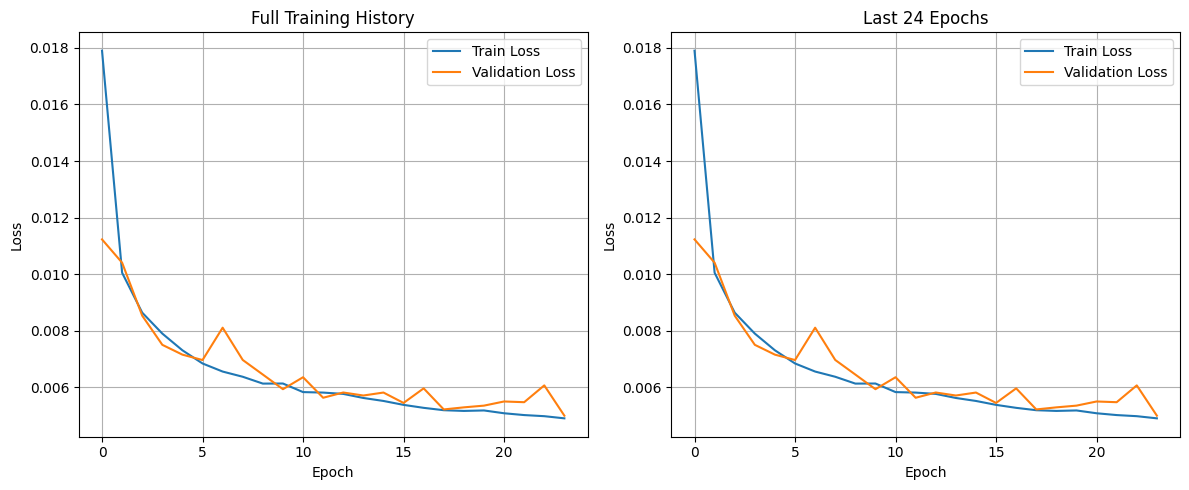

DEBUG: Plot saved and displayed successfully

Training completed in 14.11 minutes
Best validation loss: 0.004994
Completed training grouped_latent with weighted MSE


In [14]:
# Path to weight mask
weight_mask_path = "data/masks/weightMatrix.nii"

# Train optimized and light models with weighted MSE
num_epochs = 140
variants_to_train = ["optimized", "grouped_latent"]

weighted_results = []
for variant in variants_to_train:
    try:
        result = train_model_variant_weighted(variant, weight_mask_path, epochs=num_epochs)
        weighted_results.append(result)
        print(f"Completed training {variant} with weighted MSE")
        
        # Clean up
        torch.cuda.empty_cache()
        gc.collect()
        
    except Exception as e:
        print(f"Error training {variant}: {str(e)}")
        import traceback
        traceback.print_exc()

In [15]:
# Compare weighted vs unweighted
for result in weighted_results:
    variant_name = result['name'].replace('_weighted', '')
    print(f"\n{variant_name.upper()} Model:")
    print(f"  Final train loss: {result['final_train_loss']:.6f}")
    print(f"  Final val loss: {result['final_val_loss']:.6f}")
    print(f"  Training time: {result['training_time']/60:.2f} minutes")
    print(f"  Parameters: {result['parameters']:,}")


OPTIMIZED Model:
  Final train loss: 0.002013
  Final val loss: 0.002096
  Training time: 64.69 minutes
  Parameters: 1,433,129

GROUPED_LATENT Model:
  Final train loss: 0.004899
  Final val loss: 0.004994
  Training time: 14.11 minutes
  Parameters: 1,005,081


In [16]:
# Create comparison dataframe
comparison_data = []

for orig_result in results:
    if orig_result['name'] in ['optimized', 'light']:
        comparison_data.append({
            'Model': orig_result['name'],
            'Type': 'Original',
            'Final Train Loss': orig_result['final_train_loss'],
            'Final Val Loss': orig_result['final_val_loss'],
            'Training Time (min)': orig_result['training_time'] / 60,
            'Parameters': orig_result['parameters']
        })

for weighted_result in weighted_results:
    model_name = weighted_result['name'].replace('_weighted', '')
    comparison_data.append({
        'Model': model_name,
        'Type': 'Weighted',
        'Final Train Loss': weighted_result['final_train_loss'],
        'Final Val Loss': weighted_result['final_val_loss'],
        'Training Time (min)': weighted_result['training_time'] / 60,
        'Parameters': weighted_result['parameters']
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

         Model     Type  Final Train Loss  Final Val Loss  Training Time (min)  Parameters
     optimized Weighted          0.002013        0.002096            64.690552     1433129
grouped_latent Weighted          0.004899        0.004994            14.113354     1005081


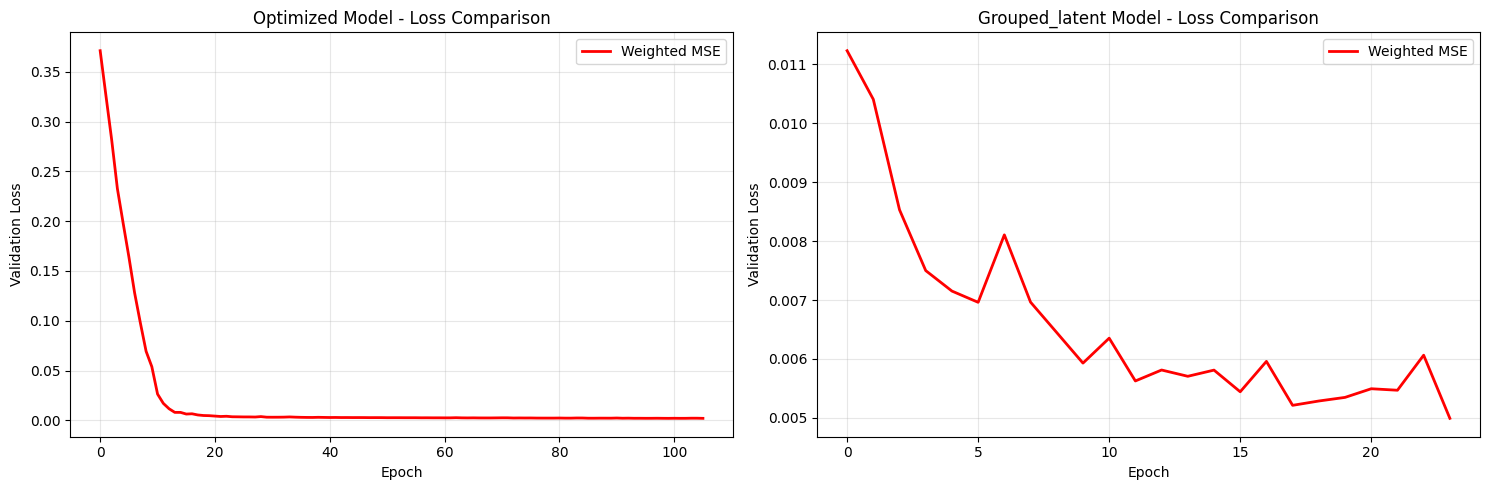

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models = ['optimized', 'grouped_latent']
colors = {'Original': 'blue', 'Weighted': 'red'}

for idx, model_name in enumerate(models):
    ax = axes[idx]
    
    # Find original result
    orig = next((r for r in results if r['name'] == model_name), None)
    # Find weighted result
    weighted = next((r for r in weighted_results if r['name'] == f'{model_name}_weighted'), None)
    
    if orig:
        ax.plot(orig['val_losses'], label='Original MSE', color=colors['Original'], linewidth=2)
    if weighted:
        ax.plot(weighted['val_losses'], label='Weighted MSE', color=colors['Weighted'], linewidth=2)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.set_title(f'{model_name.capitalize()} Model - Loss Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
for model_name in ['optimized', 'grouped_latent']:
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} MODEL COMPARISON")
    print(f"{'='*60}")
    
    orig = next((r for r in results if r['name'] == model_name), None)
    weighted = next((r for r in weighted_results if r['name'] == f'{model_name}_weighted'), None)
    
    if orig and weighted:
        print(f"\n{'Metric':<25} {'Original':<15} {'Weighted':<15} {'Difference'}")
        print(f"{'-'*70}")
        
        # Final losses
        train_diff = weighted['final_train_loss'] - orig['final_train_loss']
        val_diff = weighted['final_val_loss'] - orig['final_val_loss']
        time_diff = (weighted['training_time'] - orig['training_time']) / 60
        
        print(f"{'Final Train Loss':<25} {orig['final_train_loss']:<15.6f} {weighted['final_train_loss']:<15.6f} {train_diff:+.6f}")
        print(f"{'Final Val Loss':<25} {orig['final_val_loss']:<15.6f} {weighted['final_val_loss']:<15.6f} {val_diff:+.6f}")
        print(f"{'Training Time (min)':<25} {orig['training_time']/60:<15.2f} {weighted['training_time']/60:<15.2f} {time_diff:+.2f}")
        print(f"{'Parameters':<25} {orig['parameters']:<15,} {weighted['parameters']:<15,} {'Same'}")
        
        # Improvement percentage
        val_improvement = ((orig['final_val_loss'] - weighted['final_val_loss']) / orig['final_val_loss']) * 100
        print(f"\nValidation Loss Change: {val_improvement:+.2f}%")


OPTIMIZED MODEL COMPARISON

GROUPED_LATENT MODEL COMPARISON


NameError: name 'weighted_results' is not defined

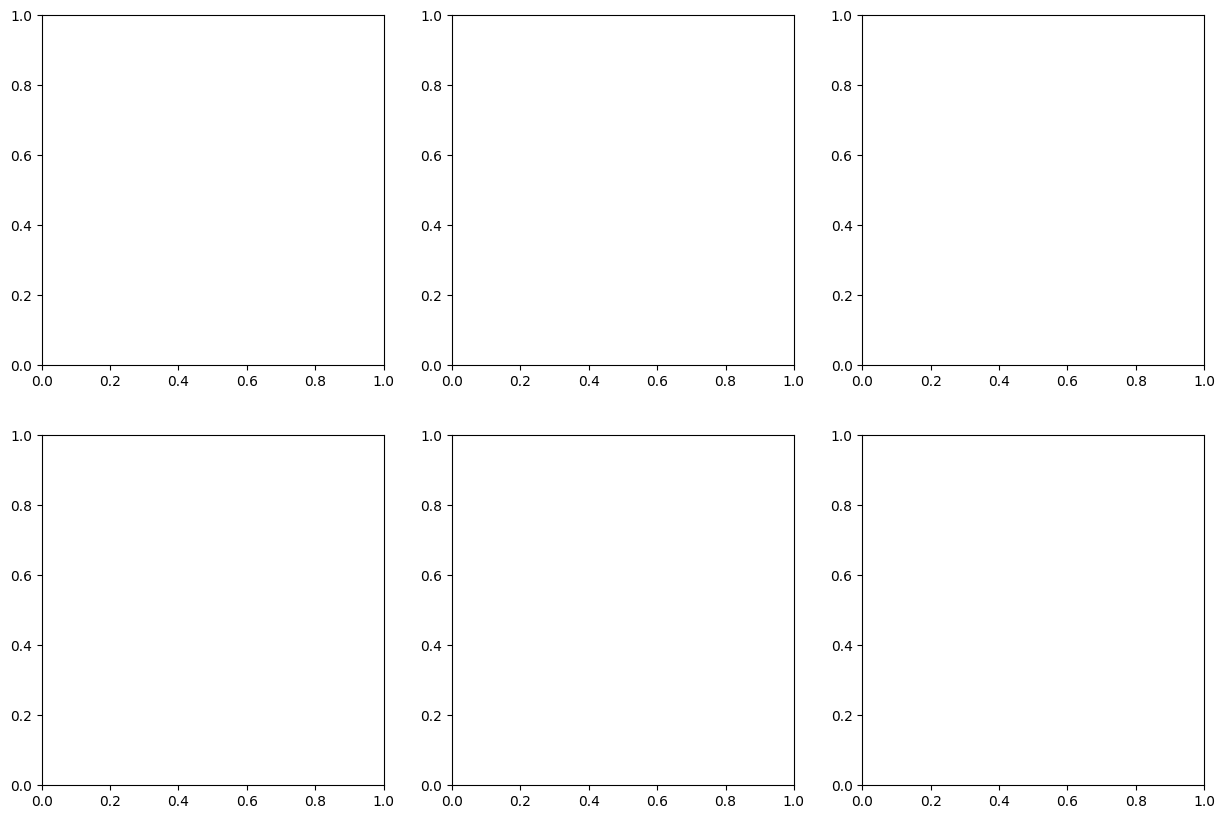

In [12]:
# Compare reconstructions on a sample
from visualization.reconstruction_visualizer import ReconstructionVisualizer

# Get a sample from validation set
sample_batch = next(iter(val_loader))
sample_volume = sample_batch['volume'][0:1].to(device)  # Take first sample

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, model_name in enumerate(['optimized']):
    # Original model
    orig = next((r for r in results if r['name'] == model_name), None)
    # Weighted model
    weighted = next((r for r in weighted_results if r['name'] == f'{model_name}_weighted'), None)
    
    if orig and weighted:
        # Reconstruct with original
        orig['model'].eval()
        with torch.no_grad():
            orig_recon = orig['model'](sample_volume)
        
        # Reconstruct with weighted
        weighted['model'].eval()
        with torch.no_grad():
            weighted_recon = weighted['model'](sample_volume)
        
        # Plot middle slice
        slice_idx = sample_volume.shape[2] // 2
        
        # Original
        axes[idx, 0].imshow(sample_volume[0, 0, slice_idx].cpu(), cmap='gray')
        axes[idx, 0].set_title(f'{model_name} - Original Input')
        axes[idx, 0].axis('off')
        
        # Original MSE reconstruction
        axes[idx, 1].imshow(orig_recon[0, 0, slice_idx].cpu(), cmap='gray')
        axes[idx, 1].set_title(f'{model_name} - Original MSE')
        axes[idx, 1].axis('off')
        
        # Weighted MSE reconstruction
        axes[idx, 2].imshow(weighted_recon[0, 0, slice_idx].cpu(), cmap='gray')
        axes[idx, 2].set_title(f'{model_name} - Weighted MSE')
        axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

In [52]:
# Overall summary
print("\n" + "="*60)
print("OVERALL SUMMARY")
print("="*60)

for model_name in ['optimized', 'light']:
    orig = next((r for r in results if r['name'] == model_name), None)
    weighted = next((r for r in weighted_results if r['name'] == f'{model_name}_weighted'), None)
    
    if orig and weighted:
        if weighted['final_val_loss'] < orig['final_val_loss']:
            print(f"✓ {model_name}: Weighted MSE IMPROVED by {((orig['final_val_loss'] - weighted['final_val_loss'])/orig['final_val_loss']*100):.2f}%")
        else:
            print(f"✗ {model_name}: Weighted MSE WORSE by {((weighted['final_val_loss'] - orig['final_val_loss'])/orig['final_val_loss']*100):.2f}%")


OVERALL SUMMARY
✓ optimized: Weighted MSE IMPROVED by 15.94%
✓ light: Weighted MSE IMPROVED by 19.04%


## 5.2. Visualization of Results

In [21]:
# Create comparison dataframe
total_data = []

for orig_result in results:
    total_data.append(orig_result)

for weighted_result in weighted_results:
    total_data.append(weighted_result)

df_total_data = pd.DataFrame(total_data)
print(df_total_data.head().to_string(index=False))

                   name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [22]:
# For each result in your results list:
for result in total_data:
    total_time = result['training_time']  # seconds
    num_epochs = len(result['train_losses'])  # actual epochs trained
    avg_epoch_time = total_time / num_epochs
    
    print(f"{result['name']}: {avg_epoch_time:.2f}s per epoch (total: {total_time/60:.2f}m, {num_epochs} epochs)")

optimized_weighted: 36.62s per epoch (total: 64.69m, 106 epochs)
grouped_latent_weighted: 35.28s per epoch (total: 14.11m, 24 epochs)


#### Compare Model Metrics

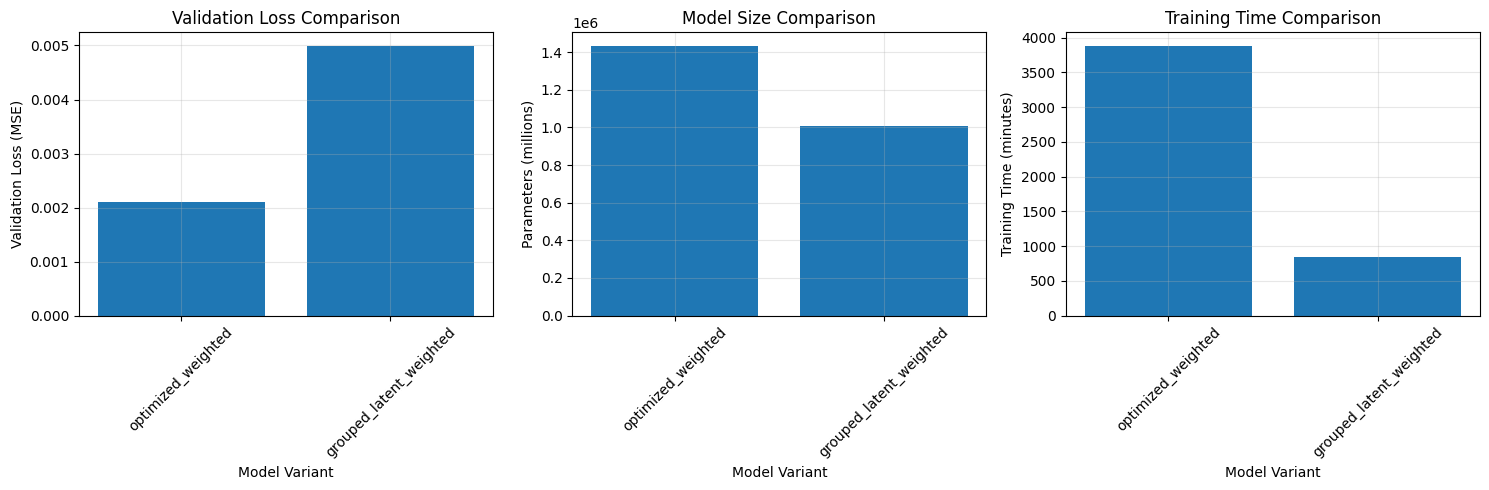

In [23]:
# Create comparison plots
plt.figure(figsize=(15, 5))

# Plot validation loss comparison
plt.subplot(1, 3, 1)
plt.bar(df_total_data["name"], df_total_data["final_val_loss"])
plt.xlabel("Model Variant")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot parameter count comparison
plt.subplot(1, 3, 2)
plt.bar(df_total_data["name"], df_total_data["parameters_millions"] if "parameters_millions" in df_total_data.columns else df_total_data["parameters"])
plt.xlabel("Model Variant")
plt.ylabel("Parameters (millions)")
plt.title("Model Size Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot training time comparison
plt.subplot(1, 3, 3)
plt.bar(df_total_data["name"], df_total_data["training_time_minutes"] if "training_time_minutes" in df_total_data.columns else df_total_data["training_time"])
plt.xlabel("Model Variant")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "metrics_comparison.png"))
plt.show()

#### Reconstruction Visualization

2025-10-09 12:13:20,510 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/NotebookLP/reconstruction_comparison.png
2025-10-09 12:13:22,252 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/NotebookLP/optimized_weighted_reconstruction.png
2025-10-09 12:13:23,614 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/NotebookLP/grouped_latent_weighted_reconstruction.png


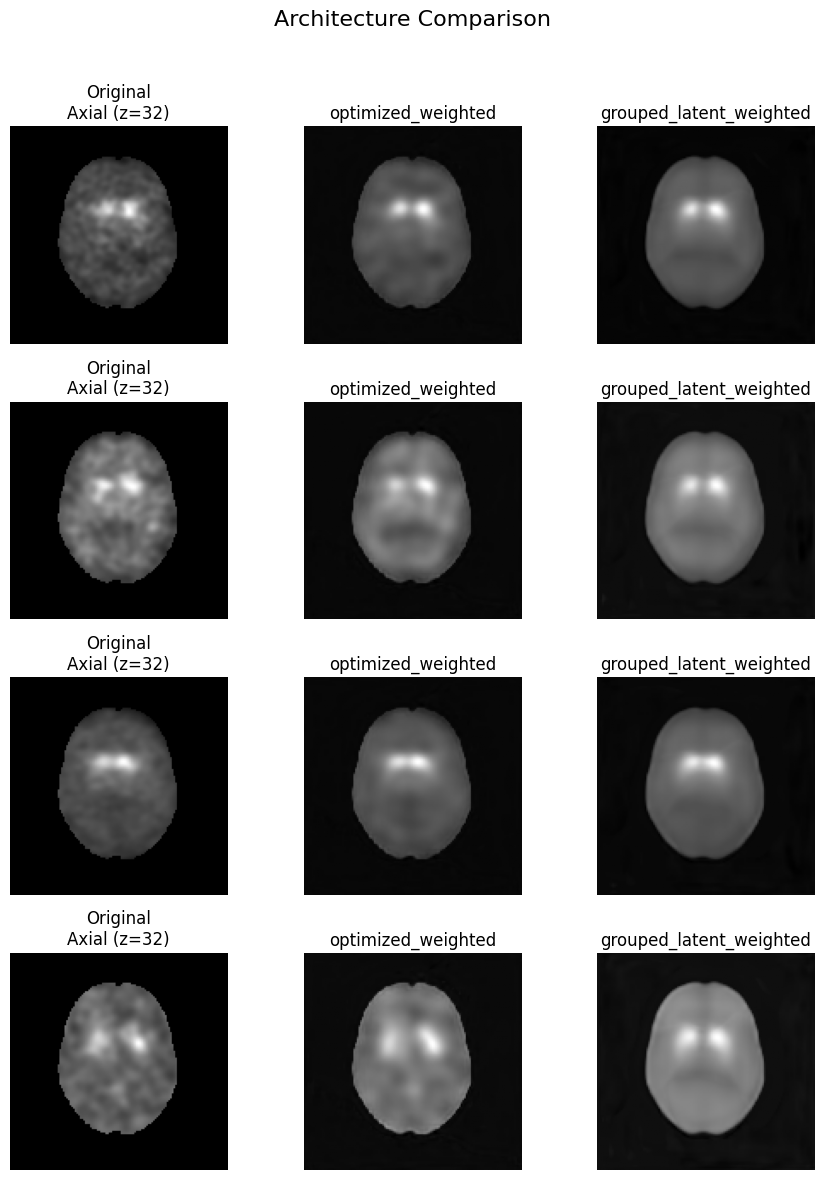

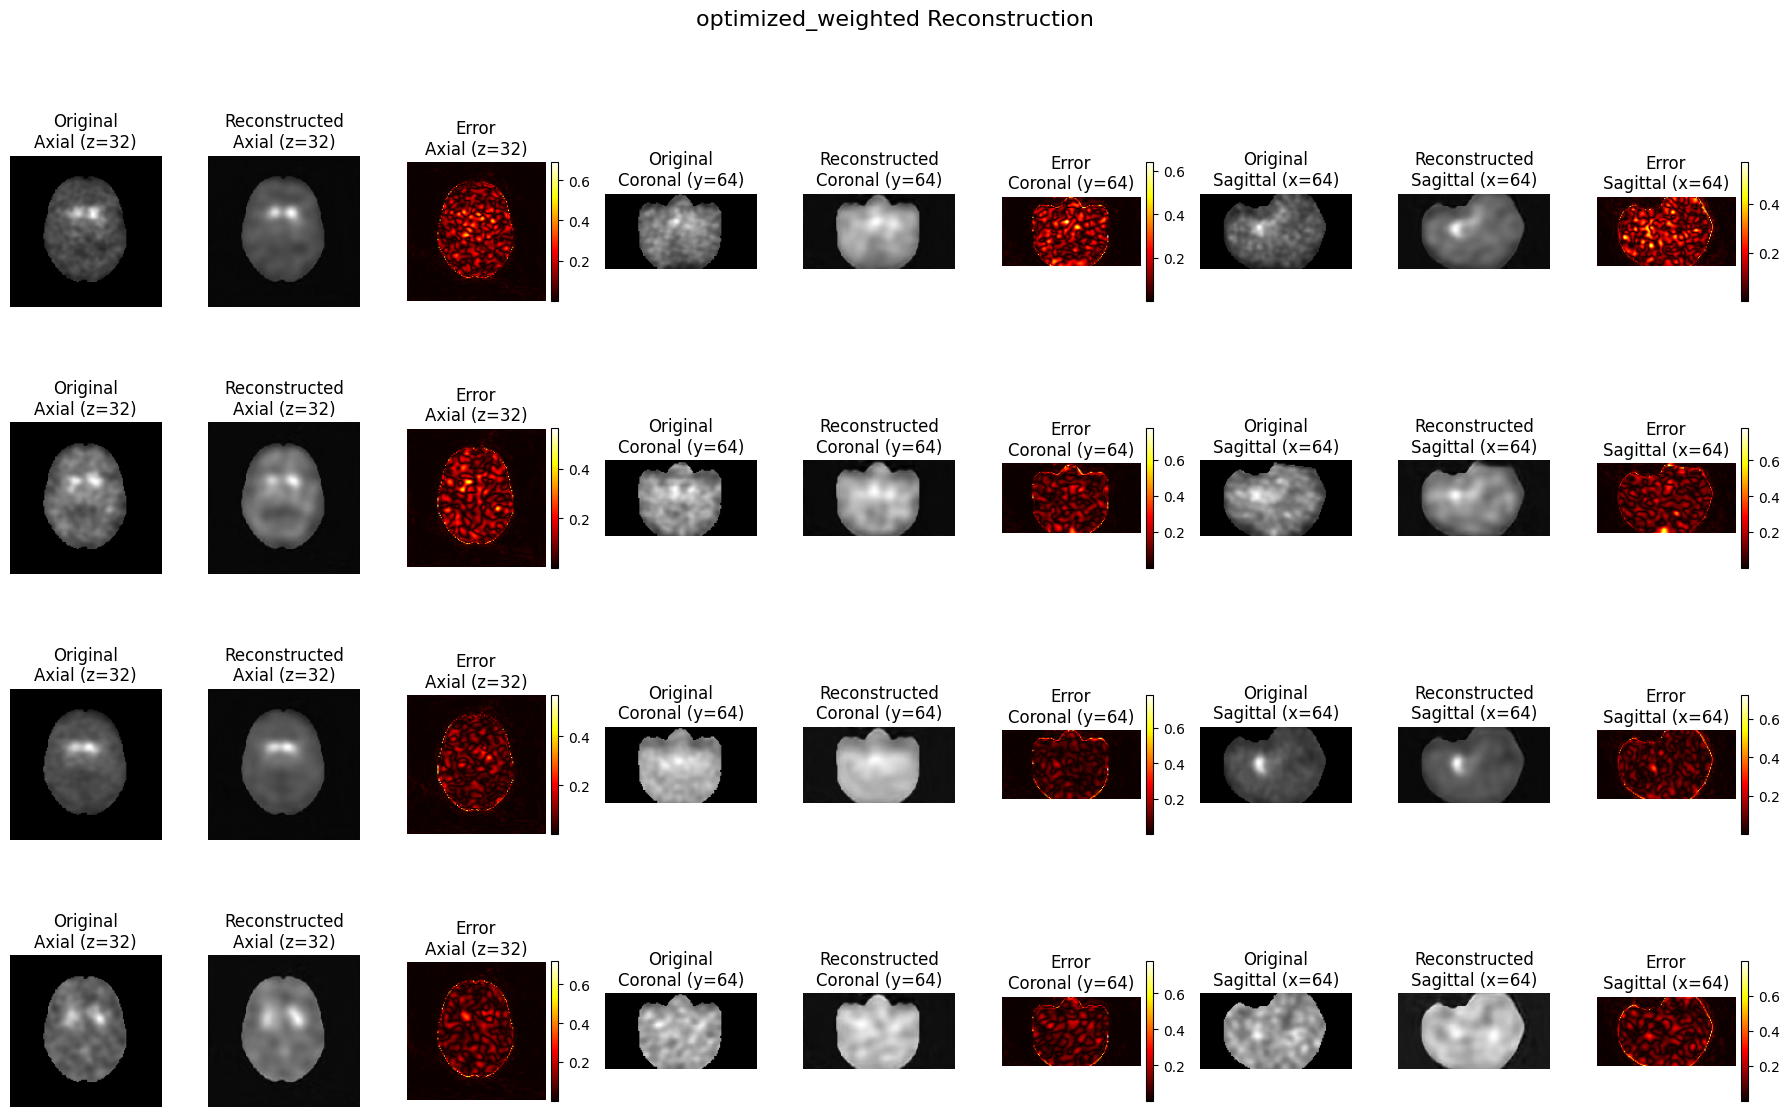

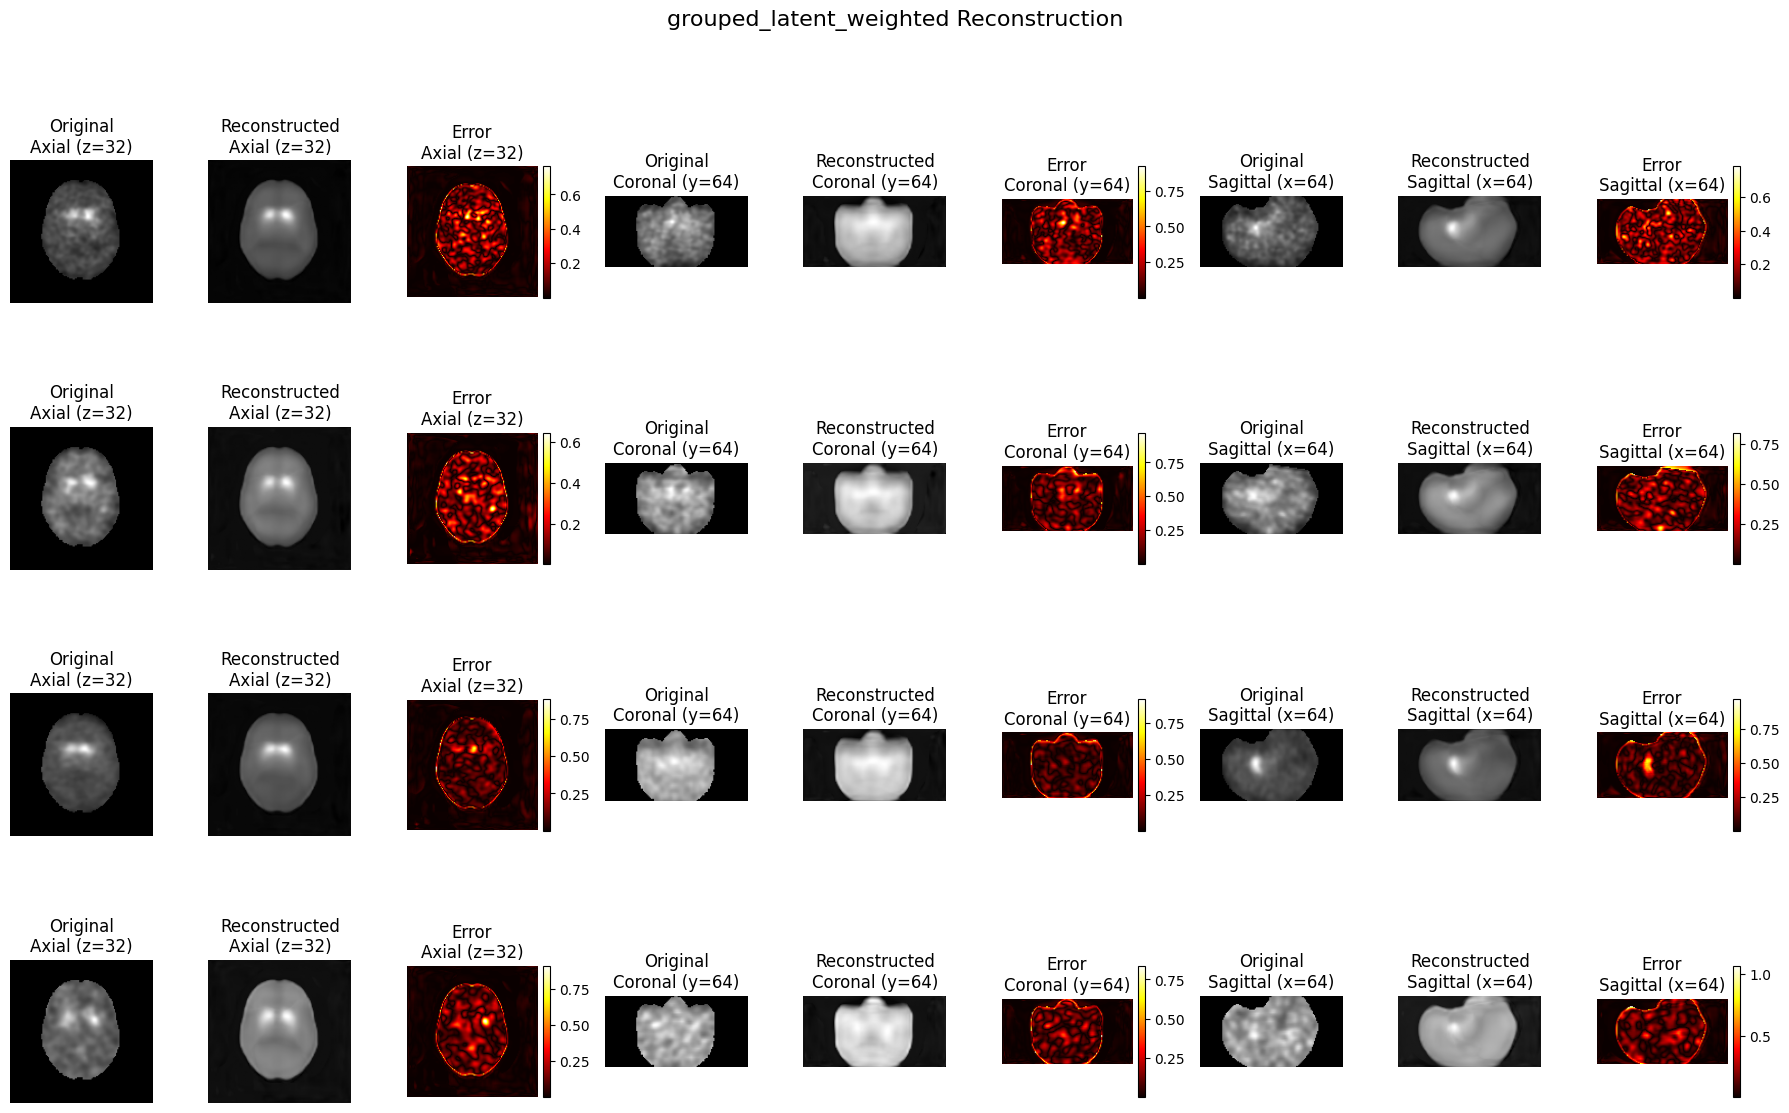

In [25]:
def visualize_reconstructions(results, sample_batch=None):
    """Visualize reconstructions from different models"""
    # Get a batch from validation set if not provided
    if sample_batch is None:
        for batch in val_loader:
            sample_batch = batch
            break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(r["name"])
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Architecture Comparison",
        save_path=os.path.join(output_dir, "reconstruction_comparison.png")
    )
    
    # Generate detailed visualizations for each variant
    for i, name in enumerate(model_names):
        visualizer.visualize_slice_comparison(
            original_volumes, reconstructions[i],
            title=f"{name} Reconstruction",
            save_path=os.path.join(output_dir, f"{name}_reconstruction.png")
        )

# Visualize reconstructions
try:
    visualize_reconstructions(total_data)
except Exception as e:
    print(f"Error visualizing reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()

## 5.3 Checkpoint loading & cross-model comparison

We can reload trained checkpoints for `optimized`, `optimized_weighted`, `grouped_latent`, and `grouped_latent_weighted` to compare their validation curves and parameter counts side by side.

In [33]:
from typing import Dict, Optional
import json

CHECKPOINT_MODELS = [
    "optimized",
    "optimized_weighted",
    "grouped_latent",
    "grouped_latent_weighted",
]

def load_checkpoint_artifacts(model_name: str, root: Path = Path(output_dir)) -> Optional[Dict]:
    model_dir = root / model_name
    metadata_path = model_dir / f"{model_name}_metadata.json"
    best_path = model_dir / f"{model_name}_best.pth"
    
    if not metadata_path.exists() or not best_path.exists():
        print(f"[WARN] Missing files for {model_name} at {model_dir}")
        return None
    
    with open(metadata_path, "r") as handle:
        metadata = json.load(handle)
    
    model = get_model_variant(model_name.split("_weighted")[0] if model_name.endswith("_weighted") else model_name)
    state_dict = torch.load(best_path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    
    return {
        "model_name": model_name,
        "model": model,
        "metadata": metadata,
        "parameters": count_parameters(model),
    }

loaded_models = {}
for name in CHECKPOINT_MODELS:
    artifacts = load_checkpoint_artifacts(name)
    if artifacts:
        loaded_models[name] = artifacts

if loaded_models:
    summary = pd.DataFrame(
        [
            {
                "model": name,
                "best_val_loss": min(artifacts["metadata"].get("val_losses", [float("inf")])),
                "final_val_loss": artifacts["metadata"].get("val_losses", [np.nan])[-1],
                "parameters": artifacts["parameters"],
            }
            for name, artifacts in loaded_models.items()
        ]
    ).sort_values("best_val_loss")
    display(summary)
else:
    print("No checkpoints loaded.")

,model,best_val_loss,final_val_loss,parameters
1,optimized_weighted,0.002096,0.002096,1433129
0,optimized,0.002512,0.002512,1433129
3,grouped_latent_weighted,0.004994,0.004994,1005081
2,grouped_latent,0.005190,0.005190,1005081


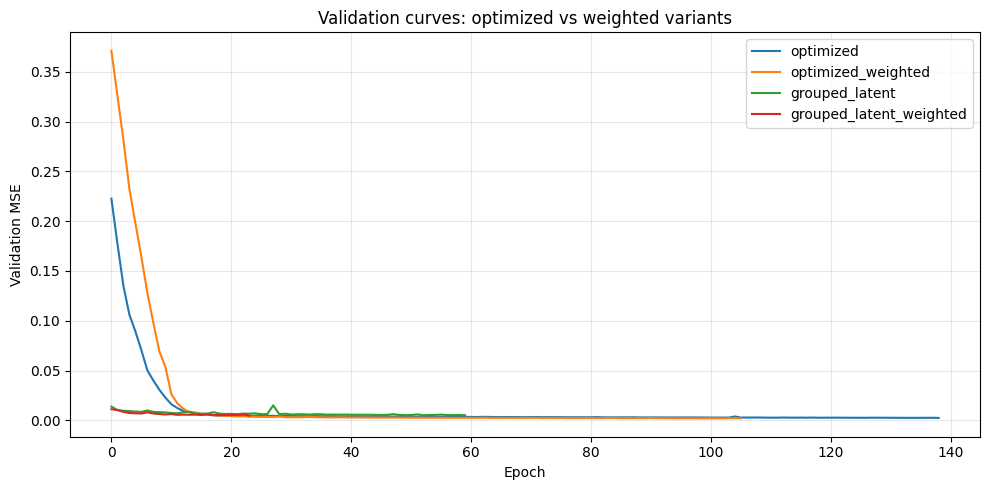

2025-10-09 13:14:30,587 - INFO - reconstruction_visualizer - Saved visualization to output/Experiments/NotebookLP/optimized_family_recon.png


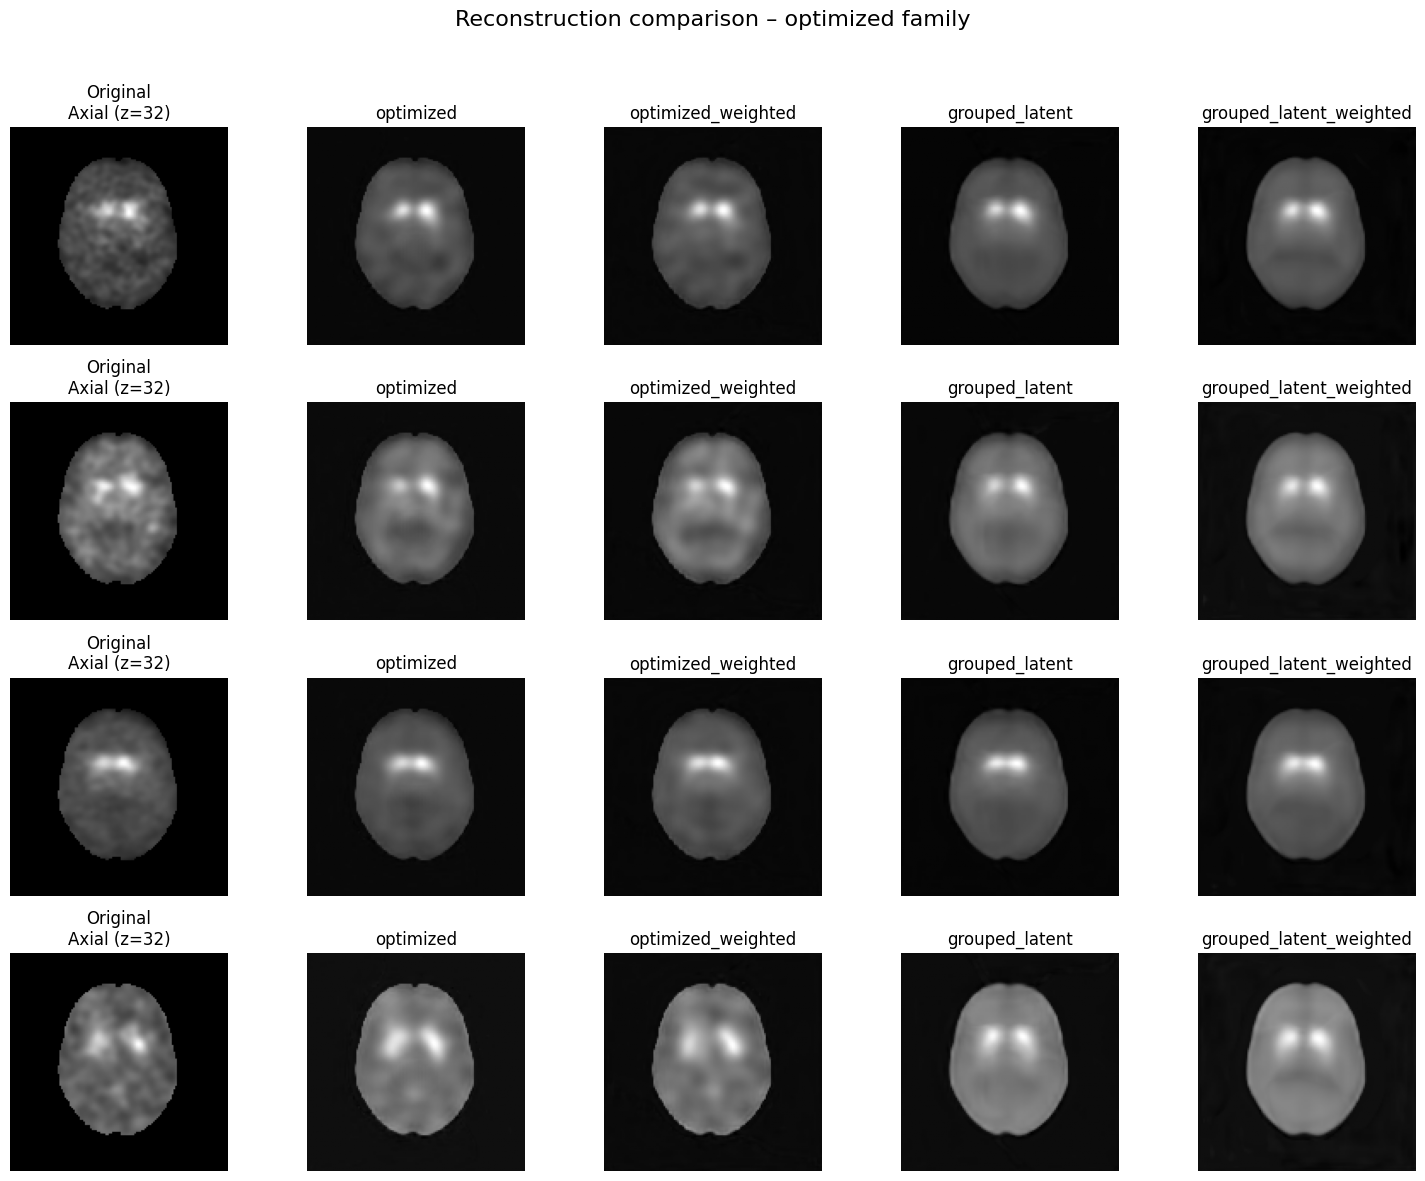

In [37]:
if not loaded_models:
    print("Load the checkpoints above first; no models available for visualization.")
else:
    plt.figure(figsize=(10, 5))
    for name, artifacts in loaded_models.items():
        val_curve = artifacts["metadata"].get("val_losses", [])
        if val_curve:
            plt.plot(val_curve, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Validation MSE")
    plt.title("Validation curves: optimized vs weighted variants")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    sample_batch = next(iter(val_loader))
    sample = sample_batch["volume"][:5].to(device)

    reconstructions = []
    labels = []
    with torch.no_grad():
        for name in CHECKPOINT_MODELS:
            if name in loaded_models:
                model = loaded_models[name]["model"]
                model.eval()
                recon = model(sample).cpu()
                reconstructions.append(recon)
                labels.append(name)

    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    visualizer.visualize_multiple_reconstructions(
        sample,
        reconstructions,
        labels,
        title="Reconstruction comparison – optimized family",
        save_path=os.path.join(output_dir, "optimized_family_recon.png")
    )

## 6. Memory Usage Analysis

In [25]:
def analyze_memory_usage(model_names):
    """Analyze memory usage during inference for different models"""
    memory_stats = []
    
    for name in model_names:
        # Create model
        model = get_model_variant(name).to(device)
        
        # Create dummy input
        dummy_input = torch.zeros((batch_size, 1, 64, 128, 128), device=device)
        
        # Warm up
        _ = model(dummy_input)
        
        # Measure memory
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()
        
        # with torch.no_grad():
        _ = model(dummy_input)
        
        memory_used = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
        
        memory_stats.append({
            "name": name,
            "memory_mb": memory_used
        })
        
        # Clean up
        del model
        torch.cuda.empty_cache()
    
    return pd.DataFrame(memory_stats)

In [27]:
# Analyze memory usage
memory_df = analyze_memory_usage(model_variants)
display(memory_df)

,name,memory_mb
0,direct,6141.423828
1,light,2995.197754
2,grouped,5886.895020
3,efficient,10472.836426
4,optimized,1869.597168
5,grouped_latent,1254.404297


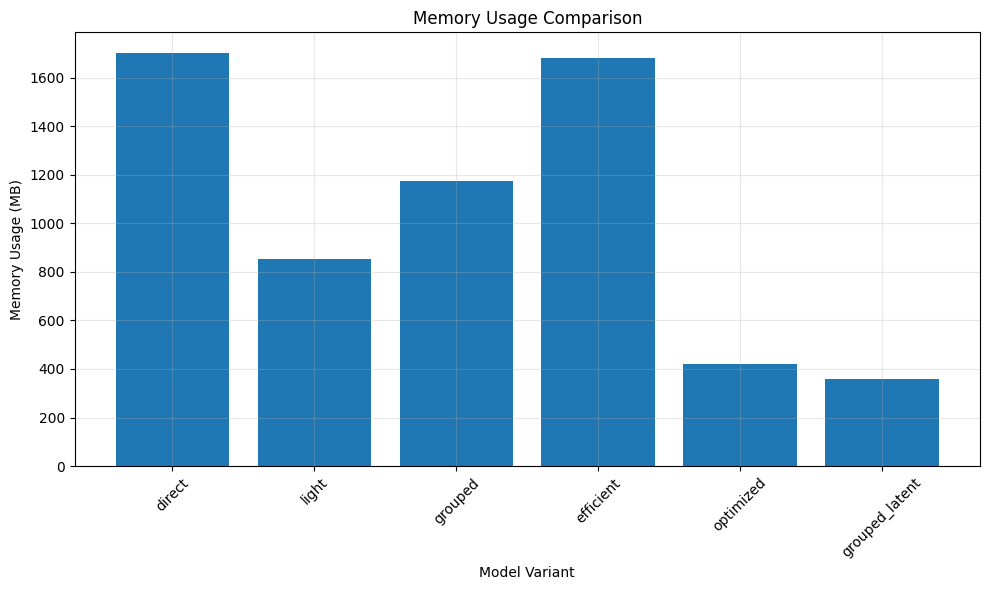

In [17]:
# Plot memory usage
plt.figure(figsize=(10, 6))
plt.bar(memory_df["name"], memory_df["memory_mb"])
plt.xlabel("Model Variant")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Comparison")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "memory_comparison.png"))
plt.show()

In [ ]:
def analyze_bottleneck_parameters():
    """Analyze parameter count in different bottleneck architectures"""
    # Create models
    direct_ae = get_model_variant("direct").to(device)
    grouped_ae = get_model_variant("grouped_latent").to(device)
    
    # Count parameters in the bottleneck section
    
    # For direct AE, the bottleneck is the connection between encoder and decoder
    # We'll count parameters in the first layer of the decoder
    direct_bottleneck_params = sum(p.numel() for p in direct_ae.decoder.up1[1].block.parameters())
    
    # For grouped AE, the bottleneck includes reshape_upsample, grouped_conv, and channel_mixer
    grouped_bottleneck_params = sum(p.numel() for p in [
        grouped_ae.decoder.grouped_conv,
        grouped_ae.decoder.channel_mixer
    ])
    
    # Calculate reduction percentage
    reduction = (1 - grouped_bottleneck_params / direct_bottleneck_params) * 100
    
    # Create a dataframe for comparison
    bottleneck_df = pd.DataFrame([
        {"name": "Direct AE", "bottleneck_params": direct_bottleneck_params},
        {"name": "Grouped Bottleneck", "bottleneck_params": grouped_bottleneck_params}
    ])
    
    display(bottleneck_df)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.bar(bottleneck_df["name"], bottleneck_df["bottleneck_params"])
    plt.title(f"Bottleneck Parameter Count Comparison\n{reduction:.1f}% reduction")
    plt.ylabel("Parameter Count")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, "bottleneck_params_comparison.png"))
    plt.show()
    
    return bottleneck_df

In [ ]:
# Analyze bottleneck parameters
try:
    bottleneck_df = analyze_bottleneck_parameters()
except Exception as e:
    print(f"Error analyzing bottleneck parameters: {str(e)}")
    import traceback
    traceback.print_exc()

#### Visualizing Latent Space Basis Images

In [ ]:
def visualize_basis_images(model_name="grouped_latent", latent_dim=16):
    """Visualize the basis images from the grouped convolution bottleneck"""
    # Create model
    model = get_model_variant(model_name).to(device)
    model.eval()
    
    # Create one-hot encoded latent representations
    basis_images = []
    
    for i in range(latent_dim):
        # Create one-hot encoding for this latent dimension
        latent = torch.zeros((1, latent_dim, 4, 8, 8), device=device)
        latent[0, i, :, :, :] = 1.0
        
        # Generate reconstruction from this one-hot encoding
        with torch.no_grad():
            # For grouped_latent model, we need to use the decoder directly
            if model_name == "grouped_latent":
                reconstruction = model.decoder(latent)
            else:
                # For other models, create a dummy encoding and replace it
                dummy = torch.zeros((1, 1, 64, 128, 128), device=device)
                encoded = model.encoder(dummy)
                encoded = latent  # Replace with our one-hot encoding
                reconstruction = model.decoder(encoded)
        
        # Add to basis images
        basis_images.append(reconstruction.cpu().numpy())
    
    # Visualize basis images
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, img in enumerate(basis_images):
        if i < len(axes):
            # Get middle slice
            slice_idx = img.shape[3] // 2
            axes[i].imshow(img[0, 0, :, :, slice_idx], cmap='gray')
            axes[i].set_title(f"Basis {i+1}")
            axes[i].axis('off')
    
    plt.suptitle("Latent Space Basis Images", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "latent_basis_images.png"))
    plt.show()

In [ ]:
# Visualize basis images
try:
    visualize_basis_images()
except Exception as e:
    print(f"Error visualizing basis images: {str(e)}")
    import traceback
    traceback.print_exc()

#### Latent Space Traversal

In [ ]:
def visualize_latent_traversal(model_name="grouped_latent", dim_idx=0):
    """Visualize the effect of traversing a single latent dimension"""
    # Create model
    model = get_model_variant(model_name).to(device)
    model.eval()
    
    # Get a sample image
    for batch in val_loader:
        sample = batch["volume"].to(device)
        break
    
    # Encode the sample
    with torch.no_grad():
        encoded = model.encoder(sample[0:1])
    
    # Create variations by traversing the selected dimension
    traversal_values = np.linspace(-3, 3, 7)
    traversal_images = []
    
    base_encoded = encoded.clone()
    
    for val in traversal_values:
        # Modify the selected dimension
        modified = base_encoded.clone()
        modified[0, dim_idx, :, :, :] = val
        
        # Decode
        with torch.no_grad():
            reconstruction = model.decoder(modified)
        
        # Add to traversal images
        traversal_images.append(reconstruction.cpu().numpy())
    
    # Visualize traversal
    fig, axes = plt.subplots(1, len(traversal_values), figsize=(15, 5))
    
    for i, (img, val) in enumerate(zip(traversal_images, traversal_values)):
        # Get middle slice
        slice_idx = img.shape[3] // 2
        axes[i].imshow(img[0, 0, :, :, slice_idx], cmap='gray')
        axes[i].set_title(f"z_{dim_idx} = {val:.1f}")
        axes[i].axis('off')
    
    plt.suptitle(f"Latent Dimension {dim_idx} Traversal", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"latent_traversal_dim{dim_idx}.png"))
    plt.show()

In [ ]:
# Visualize latent traversal for a few dimensions
try:
    for dim in [0, 1, 2]:
        visualize_latent_traversal(dim_idx=dim)
except Exception as e:
    print(f"Error visualizing latent traversal: {str(e)}")
    import traceback
    traceback.print_exc()

In [ ]:
def analyze_computational_efficiency():
    """Analyze computational efficiency of different models"""
    # Create models
    models = {
        "direct": get_model_variant("direct").to(device),
        "optimized": get_model_variant("optimized").to(device),
        "grouped_latent": get_model_variant("grouped_latent").to(device)
    }
    
    # Create dummy input
    dummy_input = torch.zeros((1, 1, 64, 128, 128), device=device)
    
    # Measure FLOPs and inference time
    results = []
    
    for name, model in models.items():
        model.eval()
        
        # Warm up
        with torch.no_grad():
            _ = model(dummy_input)
        
        # Measure inference time
        start_time = time.time()
        with torch.no_grad():
            for _ in range(10):  # Average over 10 runs
                _ = model(dummy_input)
        inference_time = (time.time() - start_time) / 10
        
        # Count parameters
        param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
        
        results.append({
            "name": name,
            "parameters": param_count,
            "inference_time_ms": inference_time * 1000
        })
    
    # Create dataframe
    efficiency_df = pd.DataFrame(results)
    display(efficiency_df)
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    plt.bar(efficiency_df["name"], efficiency_df["inference_time_ms"])
    plt.title("Inference Time Comparison")
    plt.ylabel("Inference Time (ms)")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, "inference_time_comparison.png"))
    plt.show()
    
    return efficiency_df

In [ ]:
# Analyze computational efficiency
try:
    efficiency_df = analyze_computational_efficiency()
except Exception as e:
    print(f"Error analyzing computational efficiency: {str(e)}")
    import traceback
    traceback.print_exc()

### Create Models with Different Latent Dimensions

In [ ]:
class LatentDimAutoencoder(nn.Module):
    """
    Autoencoder with configurable latent dimension.
    Uses the optimized architecture with different latent space dimensions.
    """
    def __init__(self, latent_dim=256, initial_filters=4):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Create encoder with output channels matching latent_dim
        self.encoder = OptimizedEncoder(initial_filters=initial_filters)
        
        # Create decoder with input channels matching latent_dim
        self.decoder = LatentSpaceDecoder(latent_dim=latent_dim)
        
        # Add a projection layer to map from encoder output to latent_dim
        # The encoder outputs 16 channels by default
        self.projection = nn.Conv3d(16, latent_dim, kernel_size=1)
    
    def forward(self, x):
        encoded = self.encoder(x)
        projected = self.projection(encoded)
        reconstructed = self.decoder(projected)
        return reconstructed

### Latent Dimension Experiment Function

In [ ]:
def run_latent_dim_experiment(latent_dims, epochs=5):
    """
    Run experiments with different latent space dimensions.
    
    Args:
        latent_dims: List of latent dimensions to test
        epochs: Number of epochs to train each model
    
    Returns:
        Dictionary containing results for each latent dimension
    """
    results = []
    
    for dim in latent_dims:
        print(f"\n{'='*80}\nTraining model with latent dimension {dim}\n{'='*80}")
        
        # Create model with specific latent dimension
        model = LatentDimAutoencoder(latent_dim=dim).to(device)
        
        # Create training config
        config = create_training_config(f"latent_dim_{dim}", epochs=epochs)
        
        # Record start time
        start_time = time.time()
        
        # Train model
        train_losses, val_losses, trained_model = train_autoencoder(
            model, train_loader, val_loader, config, disable_epoch_bars=False
        )
        
        # Calculate training time
        training_time = time.time() - start_time
        
        # Get final losses
        final_train_loss = train_losses[-1] if train_losses else float('inf')
        final_val_loss = val_losses[-1] if val_losses else float('inf')
        
        # Count parameters
        param_count = count_parameters(model)
        
        results.append({
            "latent_dim": dim,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "final_train_loss": final_train_loss,
            "final_val_loss": final_val_loss,
            "parameters": param_count,
            "training_time": training_time,
            "model": trained_model
        })
        
        print(f"Completed training model with latent dimension {dim}")
        
        # Clean up to free memory
        torch.cuda.empty_cache()
        gc.collect()
    
    return results

### Run Latent Dimension Experiments

In [ ]:
# Define latent dimensions to test
latent_dims = [512, 256, 128, 64, 32]

# Run experiments
latent_dim_results = run_latent_dim_experiment(latent_dims, epochs=5)

### Analyze Latent Dimension Results

In [ ]:
# Create results dataframe
latent_df = pd.DataFrame([
    {
        "latent_dim": r["latent_dim"],
        "final_train_loss": r["final_train_loss"],
        "final_val_loss": r["final_val_loss"],
        "parameters": r["parameters"],
        "parameters_millions": r["parameters"] / 1e6,
        "training_time": r["training_time"],
        "training_time_minutes": r["training_time"] / 60
    }
    for r in latent_dim_results
])

display(latent_df)

In [ ]:
# Plot validation loss vs latent dimension
plt.figure(figsize=(15, 10))

# Plot validation loss
plt.subplot(2, 2, 1)
plt.plot(latent_df["latent_dim"], latent_df["final_val_loss"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss vs Latent Dimension")
plt.xscale('log', base=2)  # Log scale for better visualization
plt.grid(True, alpha=0.3)

# Plot parameter count
plt.subplot(2, 2, 2)
plt.plot(latent_df["latent_dim"], latent_df["parameters_millions"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Parameters (millions)")
plt.title("Model Size vs Latent Dimension")
plt.xscale('log', base=2)
plt.grid(True, alpha=0.3)

# Plot training time
plt.subplot(2, 2, 3)
plt.plot(latent_df["latent_dim"], latent_df["training_time_minutes"], 'o-')
plt.xlabel("Latent Dimension")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time vs Latent Dimension")
plt.xscale('log', base=2)
plt.grid(True, alpha=0.3)

# Plot validation loss curves
plt.subplot(2, 2, 4)
for r in latent_dim_results:
    plt.plot(r["val_losses"], label=f"dim={r['latent_dim']}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Curves for Different Latent Dimensions")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "latent_dim_comparison.png"))
plt.show()

### Reconstruction Quality vs Latent Dimension

In [ ]:
def visualize_latent_dim_reconstructions(results):
    """Visualize reconstructions from models with different latent dimensions"""
    # Get a batch from validation set
    for batch in val_loader:
        sample_batch = batch
        break
    
    # Get original volumes
    original_volumes = sample_batch["volume"].to(device)
    
    # Get reconstructions from each model
    reconstructions = []
    model_names = []
    
    for r in results:
        model = r["model"]
        model.eval()
        
        with torch.no_grad():
            reconstruction = model(original_volumes)
            reconstructions.append(reconstruction)
            model_names.append(f"dim={r['latent_dim']}")
    
    # Create visualizer
    visualizer = ReconstructionVisualizer(output_dir=output_dir)
    
    # Generate comparison visualization
    visualizer.visualize_multiple_reconstructions(
        original_volumes, reconstructions, model_names,
        title="Reconstruction Quality vs Latent Dimension",
        save_path=os.path.join(output_dir, "latent_dim_reconstructions.png")
    )

In [ ]:
# Visualize latent dimension reconstructions
try:
    visualize_latent_dim_reconstructions(latent_dim_results)
except Exception as e:
    print(f"Error visualizing latent dimension reconstructions: {str(e)}")
    import traceback
    traceback.print_exc()